In [1]:
# Now using environment: argo
from rdkit import Chem

#suppl = Chem.SDMolSupplier('PptT/benchmark/all_conformers.sdf')
suppl = Chem.SDMolSupplier('PptT/benchmark/hgd_conformers.sdf')
mols = [mol for mol in suppl if mol is not None]
print(f"Read {len(mols)} molecules from SDF file")

Read 104 molecules from SDF file


In [2]:
from argo.frag_utils import SAFECodec, find_connected_rotatable_bond_ends

'''
safecodec = SAFECodec(slicer=find_connected_rotatable_bond_ends)

safecodec.encode(mols[1])
'''

/nas/longleaf/home/shuhang/miniconda3/envs/argo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'\nsafecodec = SAFECodec(slicer=find_connected_rotatable_bond_ends)\n\nsafecodec.encode(mols[1])\n'

In [3]:
find_connected_rotatable_bond_ends(mols[0])

[(1, 3), (6, 7), (10, 11)]

In [4]:
import numpy as np
from rdkit import Chem

def compute_fragment_centroids(mol, bonds, conf_id=-1, mass_weighted=False):
    # bonds: list of (atom_i, atom_j) you got from find_connected_rotatable_bond_ends
    num_atoms = mol.GetNumAtoms()

    # Build a temporary molecule with cut bonds and attach dummy atoms (*) at the cut ends
    rw = Chem.RWMol(Chem.Mol(mol))
    # Remove the bonds to split fragments
    for i, j in bonds:
        if rw.GetBondBetweenAtoms(i, j) is not None:
            rw.RemoveBond(i, j)
    # Add exit-vector dummies bound to each cut endpoint
    for i, j in bonds:
        a1 = Chem.Atom(0)
        a2 = Chem.Atom(0)
        idx1 = rw.AddAtom(a1)
        idx2 = rw.AddAtom(a2)
        rw.AddBond(i, idx1, Chem.BondType.SINGLE)
        rw.AddBond(j, idx2, Chem.BondType.SINGLE)
    fragged = rw.GetMol()

    # Get fragment membership and fragment molecules (with dummies)
    frags_idx_all = Chem.GetMolFrags(fragged, asMols=False)
    frags_mols = Chem.GetMolFrags(fragged, asMols=True, sanitizeFrags=True)

    # Map original atoms to fragments (ignore dummy atoms)
    atom_to_frag = [-1] * num_atoms
    for frag_idx, frag in enumerate(frags_idx_all):
        for a in frag:
            if a < num_atoms:
                atom_to_frag[a] = frag_idx

    # Count exit vectors per fragment (each cut contributes one to each side)
    exit_counts = [0] * len(frags_idx_all)
    for i, j in bonds:
        fi = atom_to_frag[i]
        fj = atom_to_frag[j]
        if fi != -1:
            exit_counts[fi] += 1
        if fj != -1:
            exit_counts[fj] += 1

    # Coordinates from the original conformer
    conf = mol.GetConformer(conf_id)
    positions = np.array([list(conf.GetAtomPosition(i)) for i in range(num_atoms)])

    masses = None
    if mass_weighted:
        masses = np.array([mol.GetAtomWithIdx(i).GetMass() for i in range(num_atoms)])

    results = []
    for frag_idx, frag in enumerate(frags_idx_all):
        # Use only original atoms (exclude dummy atoms appended to fragged)
        idxs_list = [a for a in frag if a < num_atoms]
        idxs = np.array(idxs_list, dtype=int)
        if mass_weighted:
            w = masses[idxs][:, None]
            centroid = (positions[idxs] * w).sum(axis=0) / w.sum()
        else:
            centroid = positions[idxs].mean(axis=0)
        # SMILES with exit vectors ([*]) preserved
        frag_smiles = Chem.MolToSmiles(frags_mols[frag_idx], isomericSmiles=True, canonical=True)
        results.append((tuple(idxs_list), centroid, exit_counts[frag_idx], frag_smiles))
    return results

# Usage
# ends = find_connected_rotatable_bond_ends(mol)
# centroids = compute_fragment_centroids(mol, ends)

In [5]:
ends = find_connected_rotatable_bond_ends(mols[1])
print(ends)

[(3, 4), (7, 8), (20, 21)]


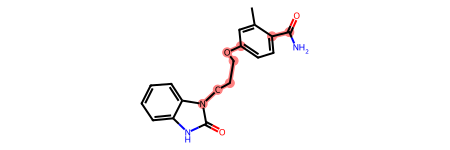

In [6]:
mols[1]

In [7]:
centroids = compute_fragment_centroids(mols[1], ends)

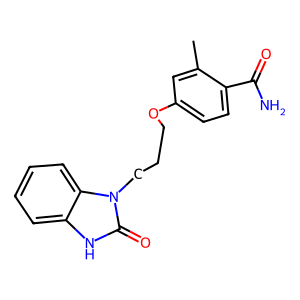

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw

Draw.MolToImage(mols[1])

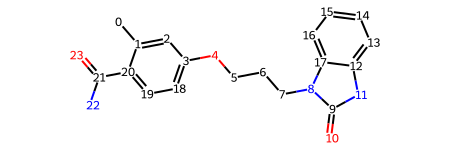

In [9]:
mol = Chem.MolFromSmiles(Chem.MolToSmiles(mols[1]))
for atom in mol.GetAtoms():
    atom.SetProp('atomLabel', str(atom.GetIdx()))
mol

In [10]:
print(centroids)

[((0, 1, 2, 3, 18, 19, 20), array([6.91357143, 1.778     , 8.65771429]), 2, '*c1ccc(*)c(C)c1'), ((4, 5, 6, 7), array([ 4.97775, -0.59075,  5.3625 ]), 2, '*CCCO*'), ((8, 9, 10, 11, 12, 13, 14, 15, 16, 17), array([ 1.7304, -3.2263,  4.6505]), 1, '*n1c(=O)[nH]c2ccccc21'), ((21, 22, 23), array([ 9.50133333,  2.10133333, 10.40833333]), 1, '*C(N)=O')]


In [11]:
centroids[1]

((4, 5, 6, 7), array([ 4.97775, -0.59075,  5.3625 ]), 2, '*CCCO*')

In [12]:
# Create dictionary to store fragments by number of exit vectors
fragments_by_exits = {}

# Iterate through all molecules
for mol in mols[0:50]:
    # Get rotatable bond ends
    ends = find_connected_rotatable_bond_ends(mol)
    
    # Get centroids for each fragment
    centroids = compute_fragment_centroids(mol, ends)
    
    # Store each fragment
    for frag_atoms, centroid, n_exits, smiles in centroids:
        if n_exits not in fragments_by_exits:
            fragments_by_exits[n_exits] = []
        
        fragments_by_exits[n_exits].append({
            'smiles': smiles,
            'centroid': centroid
        })

# Print summary
for n_exits in sorted(fragments_by_exits.keys()):
    print(f"Fragments with {n_exits} exit vectors: {len(fragments_by_exits[n_exits])}")

Fragments with 1 exit vectors: 106
Fragments with 2 exit vectors: 102
Fragments with 3 exit vectors: 6


In [13]:
fragments_by_exits[1]

[{'smiles': '*C(N)=O',
  'centroid': array([ 9.515     ,  2.13533333, 10.38333333])},
 {'smiles': '*n1c(=O)[nH]c2c(Cl)cccc21',
  'centroid': array([ 1.56381818, -3.27281818,  4.67872727])},
 {'smiles': '*n1c(=O)[nH]c2ccccc21',
  'centroid': array([ 1.7304, -3.2263,  4.6505])},
 {'smiles': '*C(N)=O',
  'centroid': array([ 9.50133333,  2.10133333, 10.40833333])},
 {'smiles': '*CC', 'centroid': array([3.6965, 1.432 , 5.1945])},
 {'smiles': '*n1c(=O)[nH]c2ccccc21',
  'centroid': array([ 1.7416, -3.4455,  4.6725])},
 {'smiles': '*C(N)=O',
  'centroid': array([ 9.29666667,  2.24533333, 10.38166667])},
 {'smiles': '*C(N)=O',
  'centroid': array([ 9.13666667,  2.153     , 10.44433333])},
 {'smiles': '*n1c(=O)[nH]c2ccccc21',
  'centroid': array([ 1.7896, -3.3853,  4.7438])},
 {'smiles': '*C(N)=O', 'centroid': array([ 9.517,  2.117, 10.398])},
 {'smiles': '*n1c(=O)[nH]c2cccc(Cl)c21',
  'centroid': array([ 1.80890909, -2.92909091,  4.597     ])},
 {'smiles': '*C(N)=O',
  'centroid': array([ 9.554


Sample of fragments with 1 exit vector:


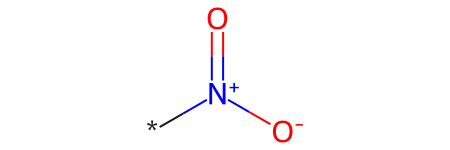

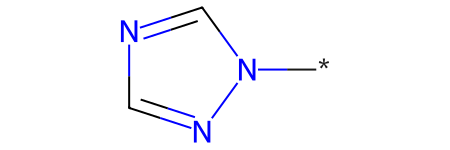

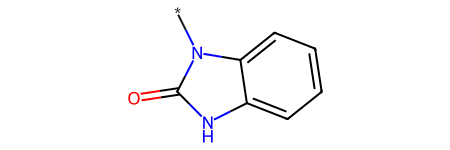

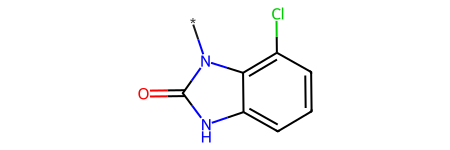

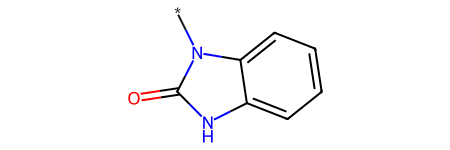

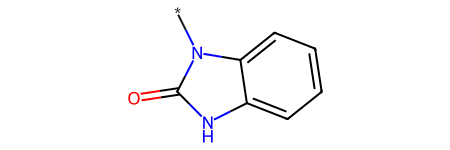

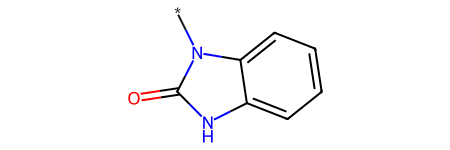

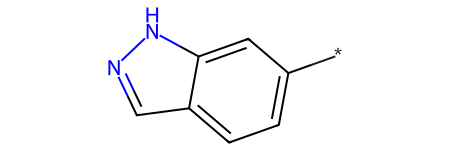

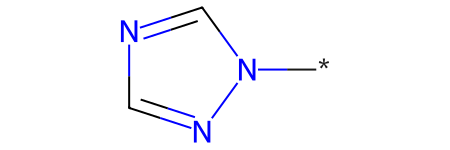

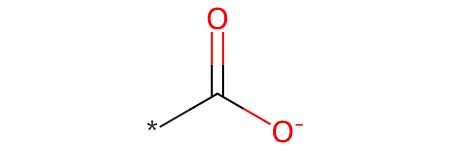


Sample of fragments with 2 exit vectors:


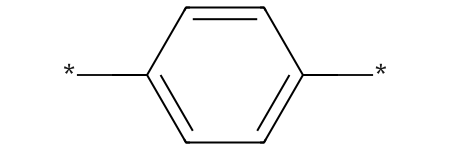

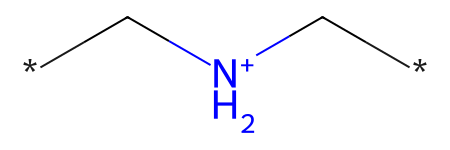

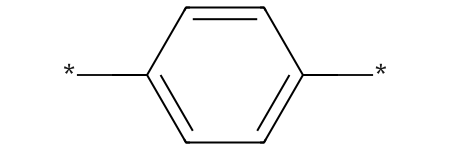

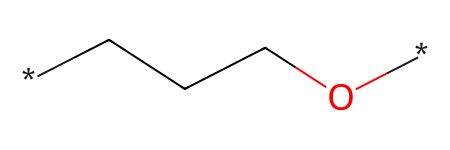

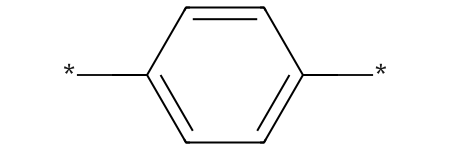

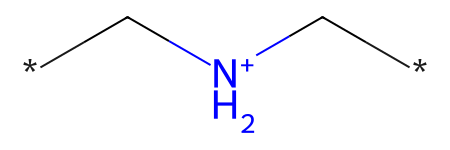

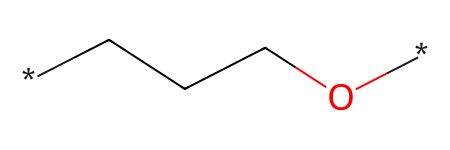

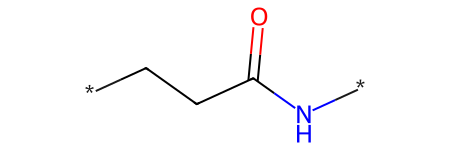

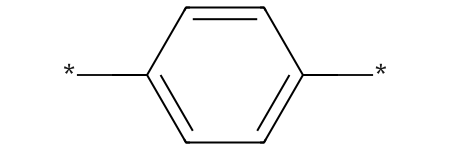

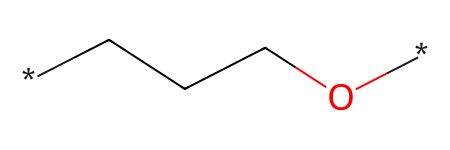


All fragments with 3 exit vectors:


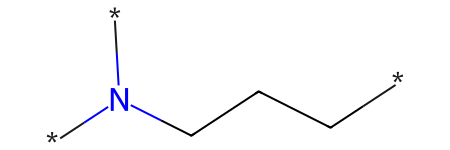

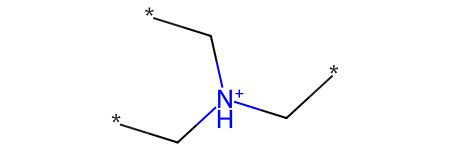

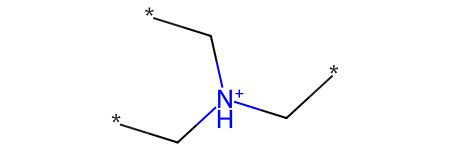

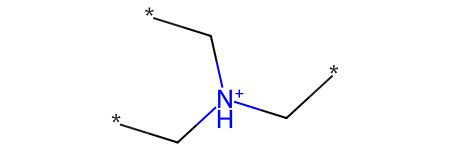

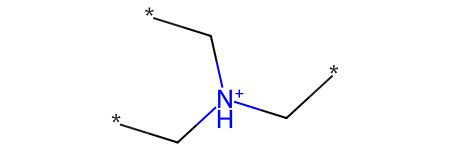

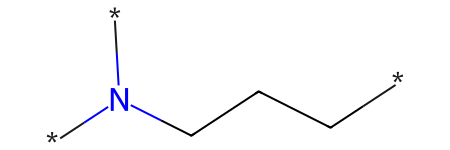

In [14]:
import random

# Sample and draw fragments with 1 exit vector
print("\nSample of fragments with 1 exit vector:")
sample_1exit = random.sample(fragments_by_exits[1], min(10, len(fragments_by_exits[1])))
for frag in sample_1exit:
    mol = Chem.MolFromSmiles(frag['smiles'])
    display(mol)

# Sample and draw fragments with 2 exit vectors
print("\nSample of fragments with 2 exit vectors:")
sample_2exit = random.sample(fragments_by_exits[2], min(10, len(fragments_by_exits[2])))
for frag in sample_2exit:
    mol = Chem.MolFromSmiles(frag['smiles'])
    display(mol)

# Draw all fragments with 3 exit vectors
print("\nAll fragments with 3 exit vectors:")
for frag in fragments_by_exits[3]:
    mol = Chem.MolFromSmiles(frag['smiles'])
    display(mol)

In [15]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

def cluster_fragments(fragments, threshold=1.0):
    # Extract centroids into array
    centroids = np.array([f['centroid'] for f in fragments])
    
    # Perform clustering
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=threshold,
        metric='euclidean',
        linkage='single'
    )
    
    # Get cluster labels
    labels = clustering.fit_predict(centroids)
    
    # Group fragments by cluster
    clusters = {}
    for i, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(fragments[i])
        
    return clusters

# Cluster fragments for each exit vector category
clustered_fragments = {}
for n_exits, frags in fragments_by_exits.items():
    print(f"\nClustering fragments with {n_exits} exit vectors:")
    clusters = cluster_fragments(frags)
    clustered_fragments[n_exits] = clusters
    print(f"Found {len(clusters)} clusters")
    
    # Print size of each cluster
    for cluster_id, cluster in clusters.items():
        print(f"Cluster {cluster_id}: {len(cluster)} fragments")


Clustering fragments with 1 exit vectors:
Found 18 clusters
Cluster 1: 23 fragments
Cluster 0: 40 fragments
Cluster 13: 1 fragments
Cluster 11: 1 fragments
Cluster 10: 3 fragments
Cluster 7: 18 fragments
Cluster 9: 2 fragments
Cluster 4: 4 fragments
Cluster 12: 1 fragments
Cluster 15: 1 fragments
Cluster 17: 1 fragments
Cluster 2: 2 fragments
Cluster 16: 1 fragments
Cluster 3: 4 fragments
Cluster 8: 1 fragments
Cluster 5: 1 fragments
Cluster 14: 1 fragments
Cluster 6: 1 fragments

Clustering fragments with 2 exit vectors:
Found 18 clusters
Cluster 1: 28 fragments
Cluster 6: 45 fragments
Cluster 10: 1 fragments
Cluster 0: 4 fragments
Cluster 2: 6 fragments
Cluster 14: 1 fragments
Cluster 15: 1 fragments
Cluster 13: 1 fragments
Cluster 16: 1 fragments
Cluster 4: 3 fragments
Cluster 17: 1 fragments
Cluster 12: 1 fragments
Cluster 3: 2 fragments
Cluster 5: 3 fragments
Cluster 11: 1 fragments
Cluster 9: 1 fragments
Cluster 7: 1 fragments
Cluster 8: 1 fragments

Clustering fragments with 3 

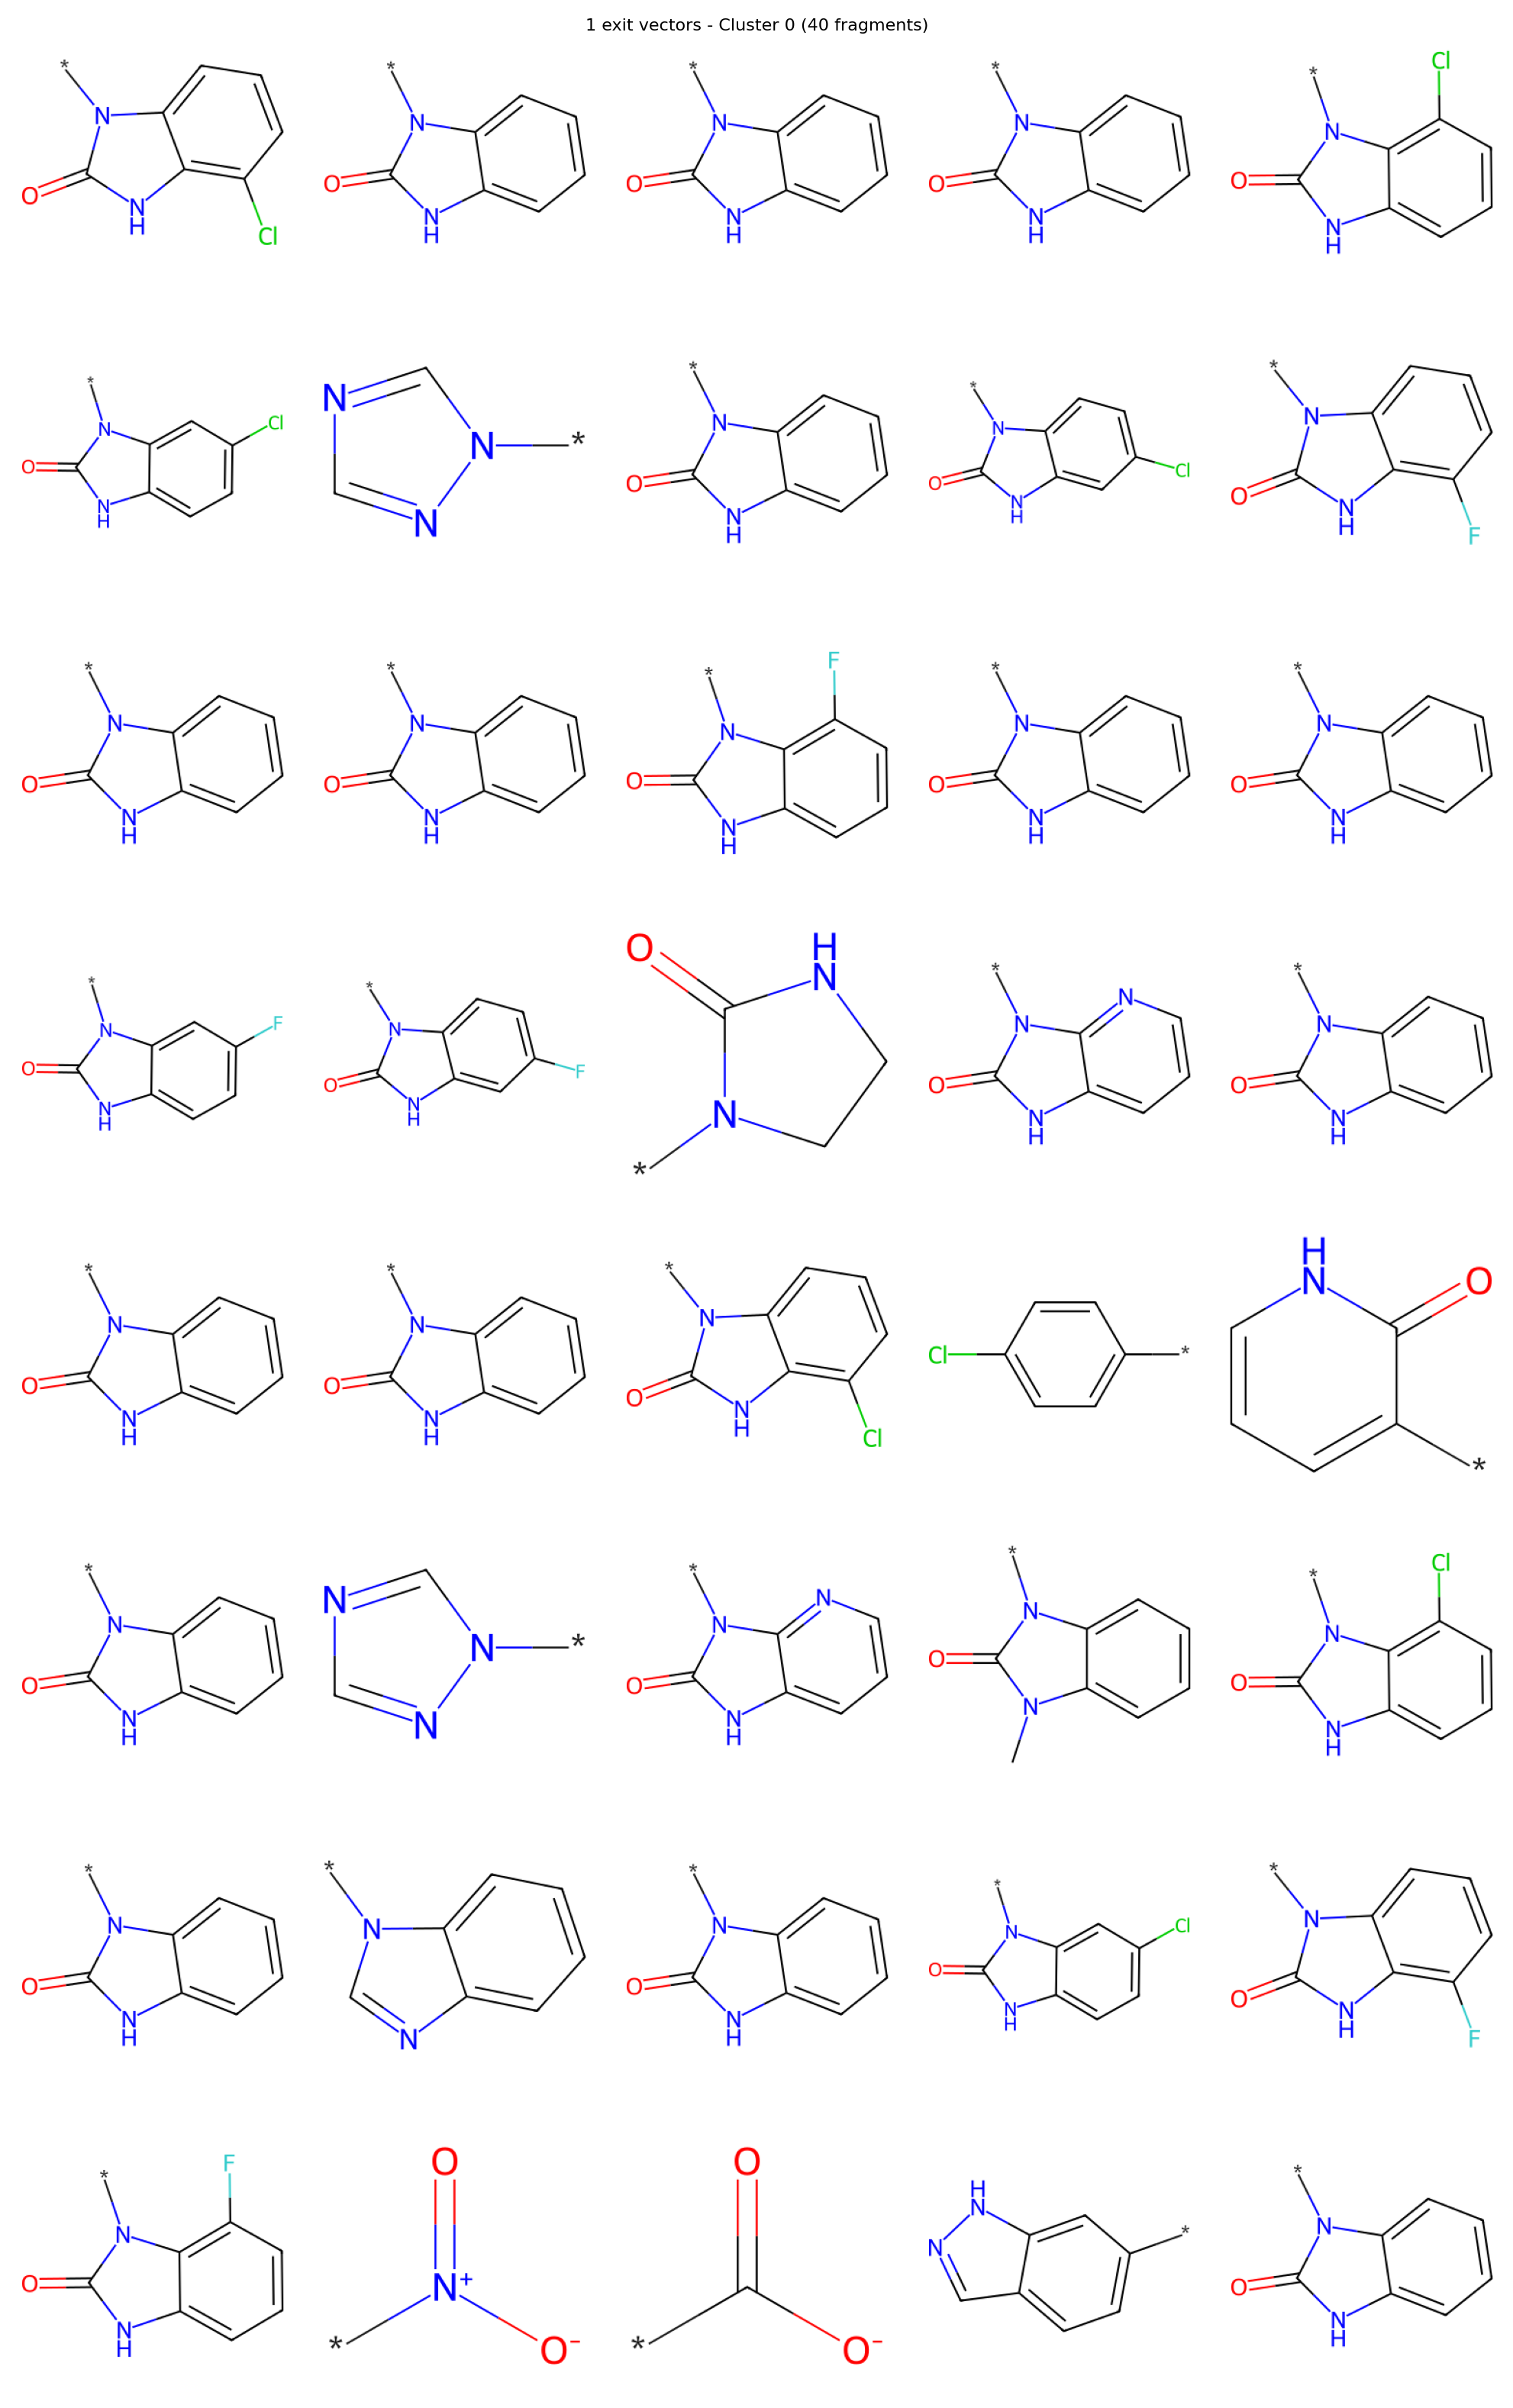

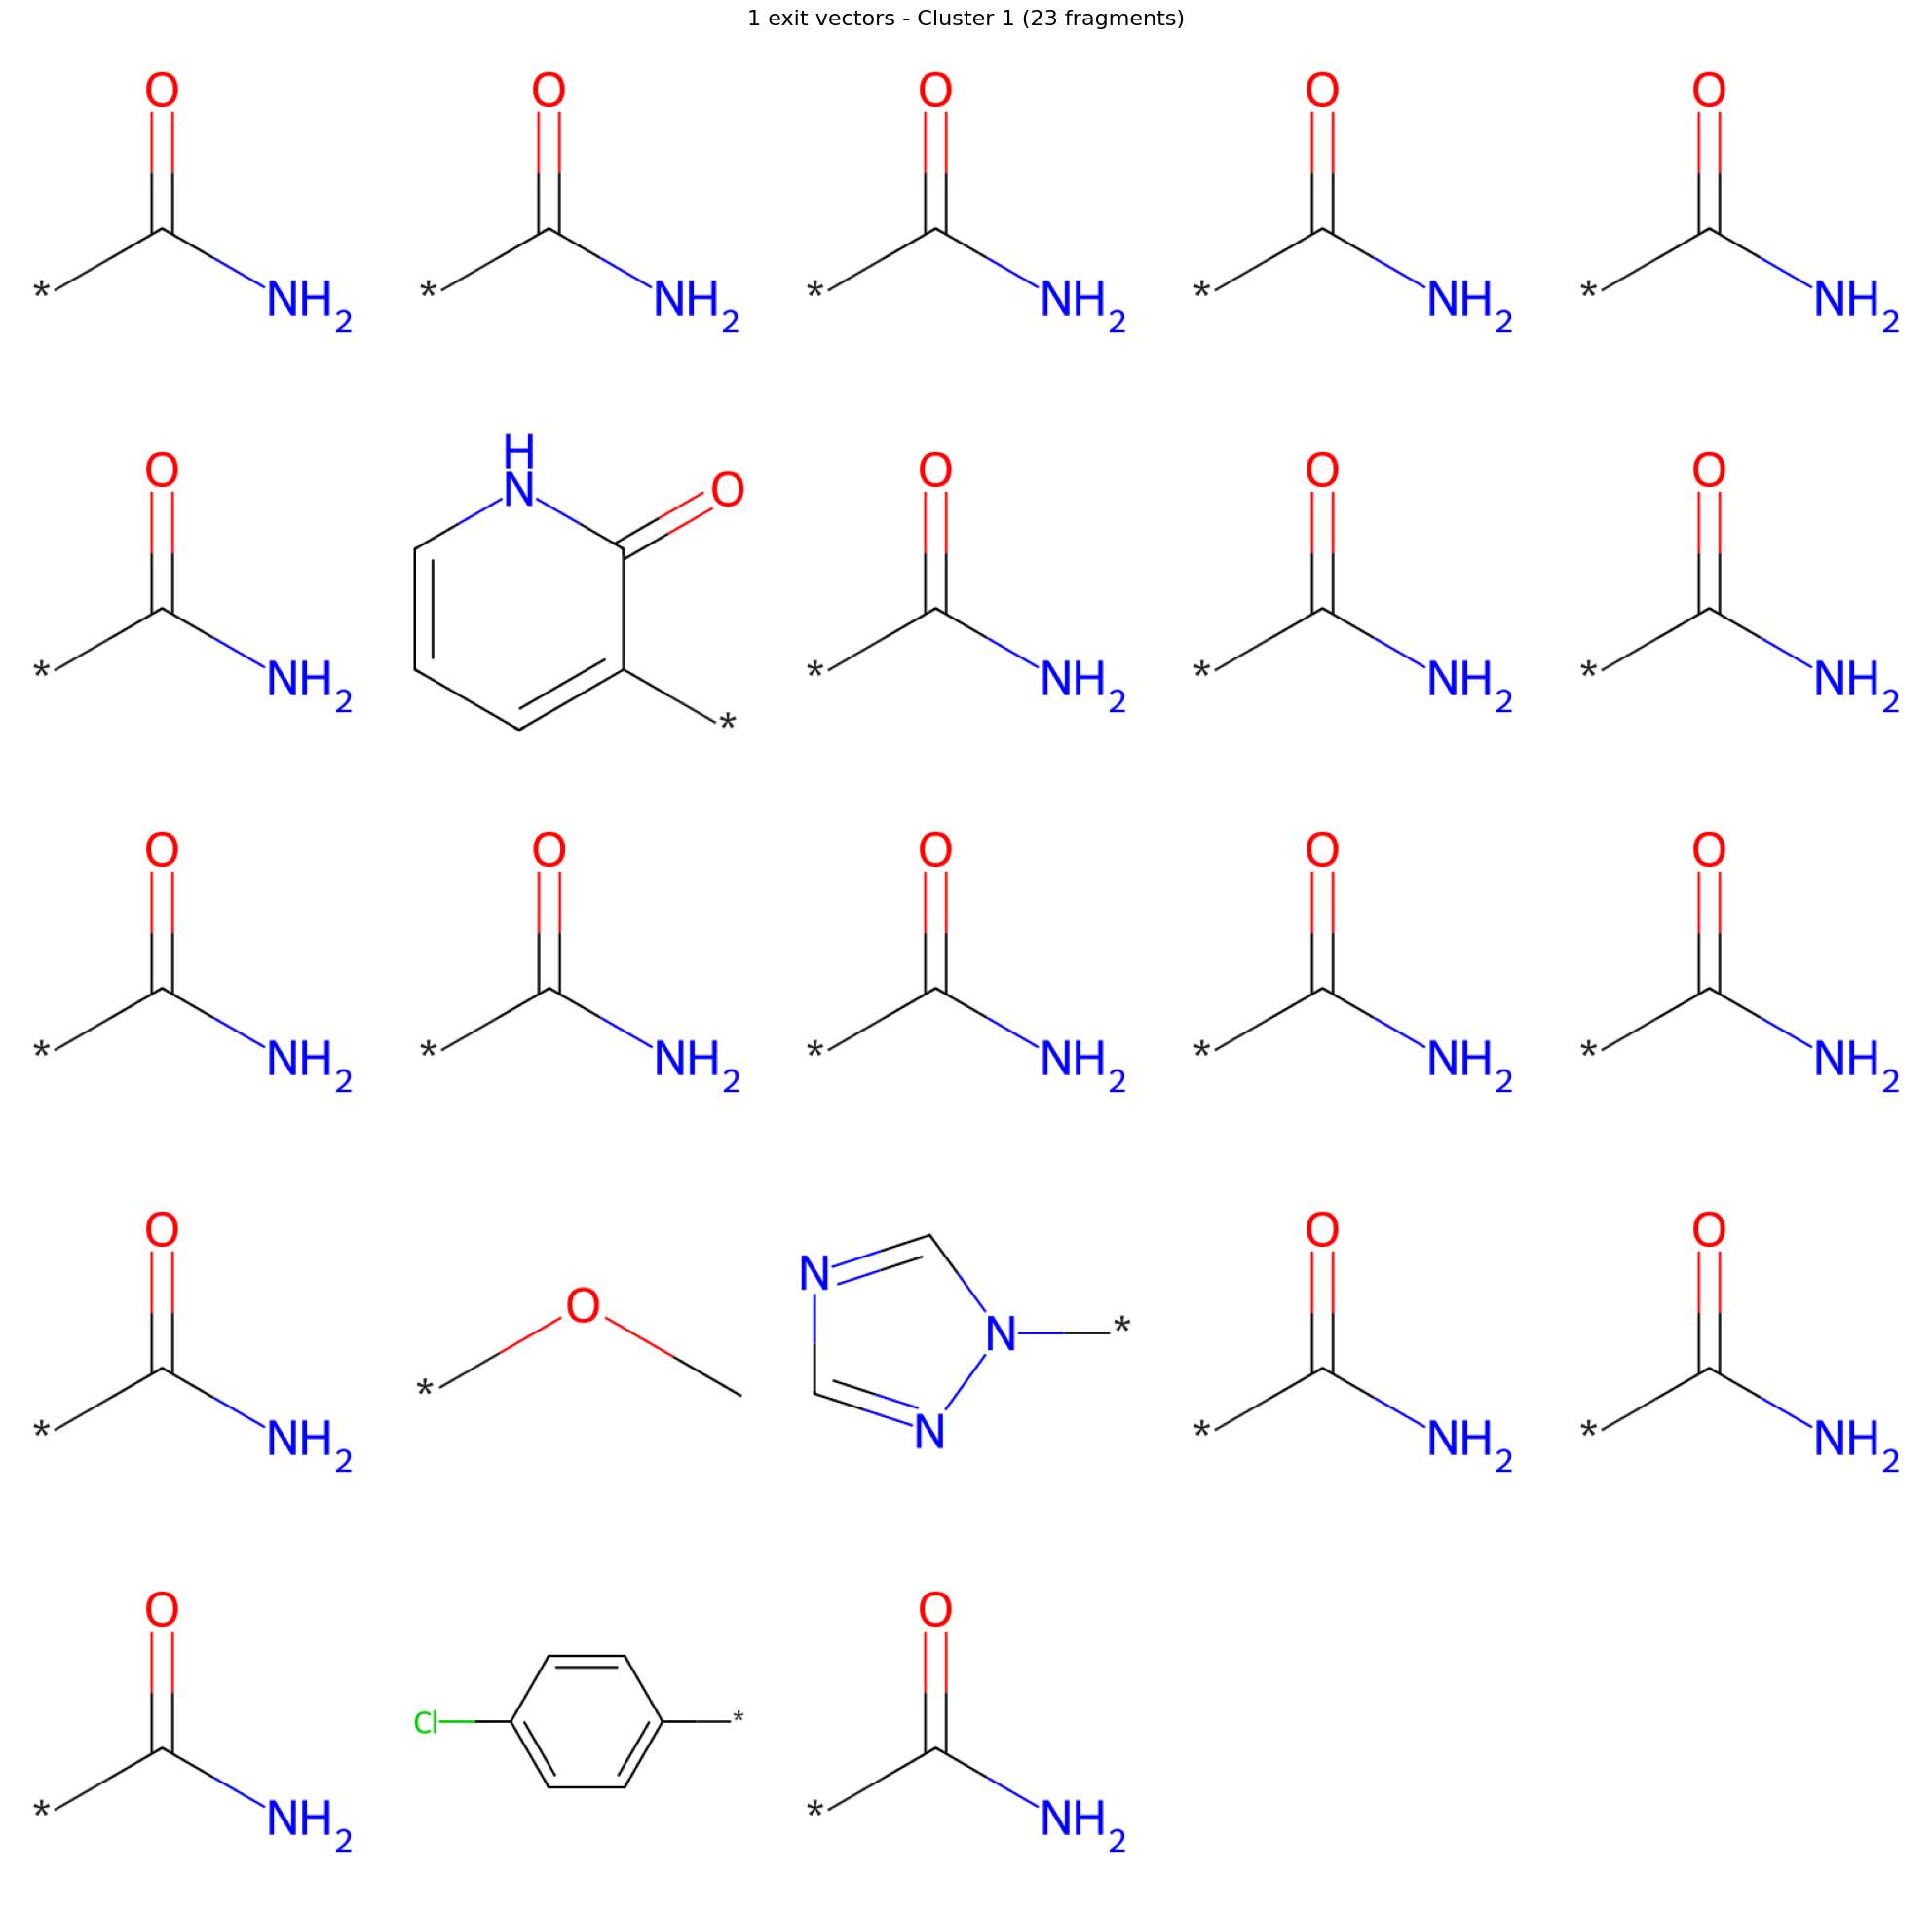

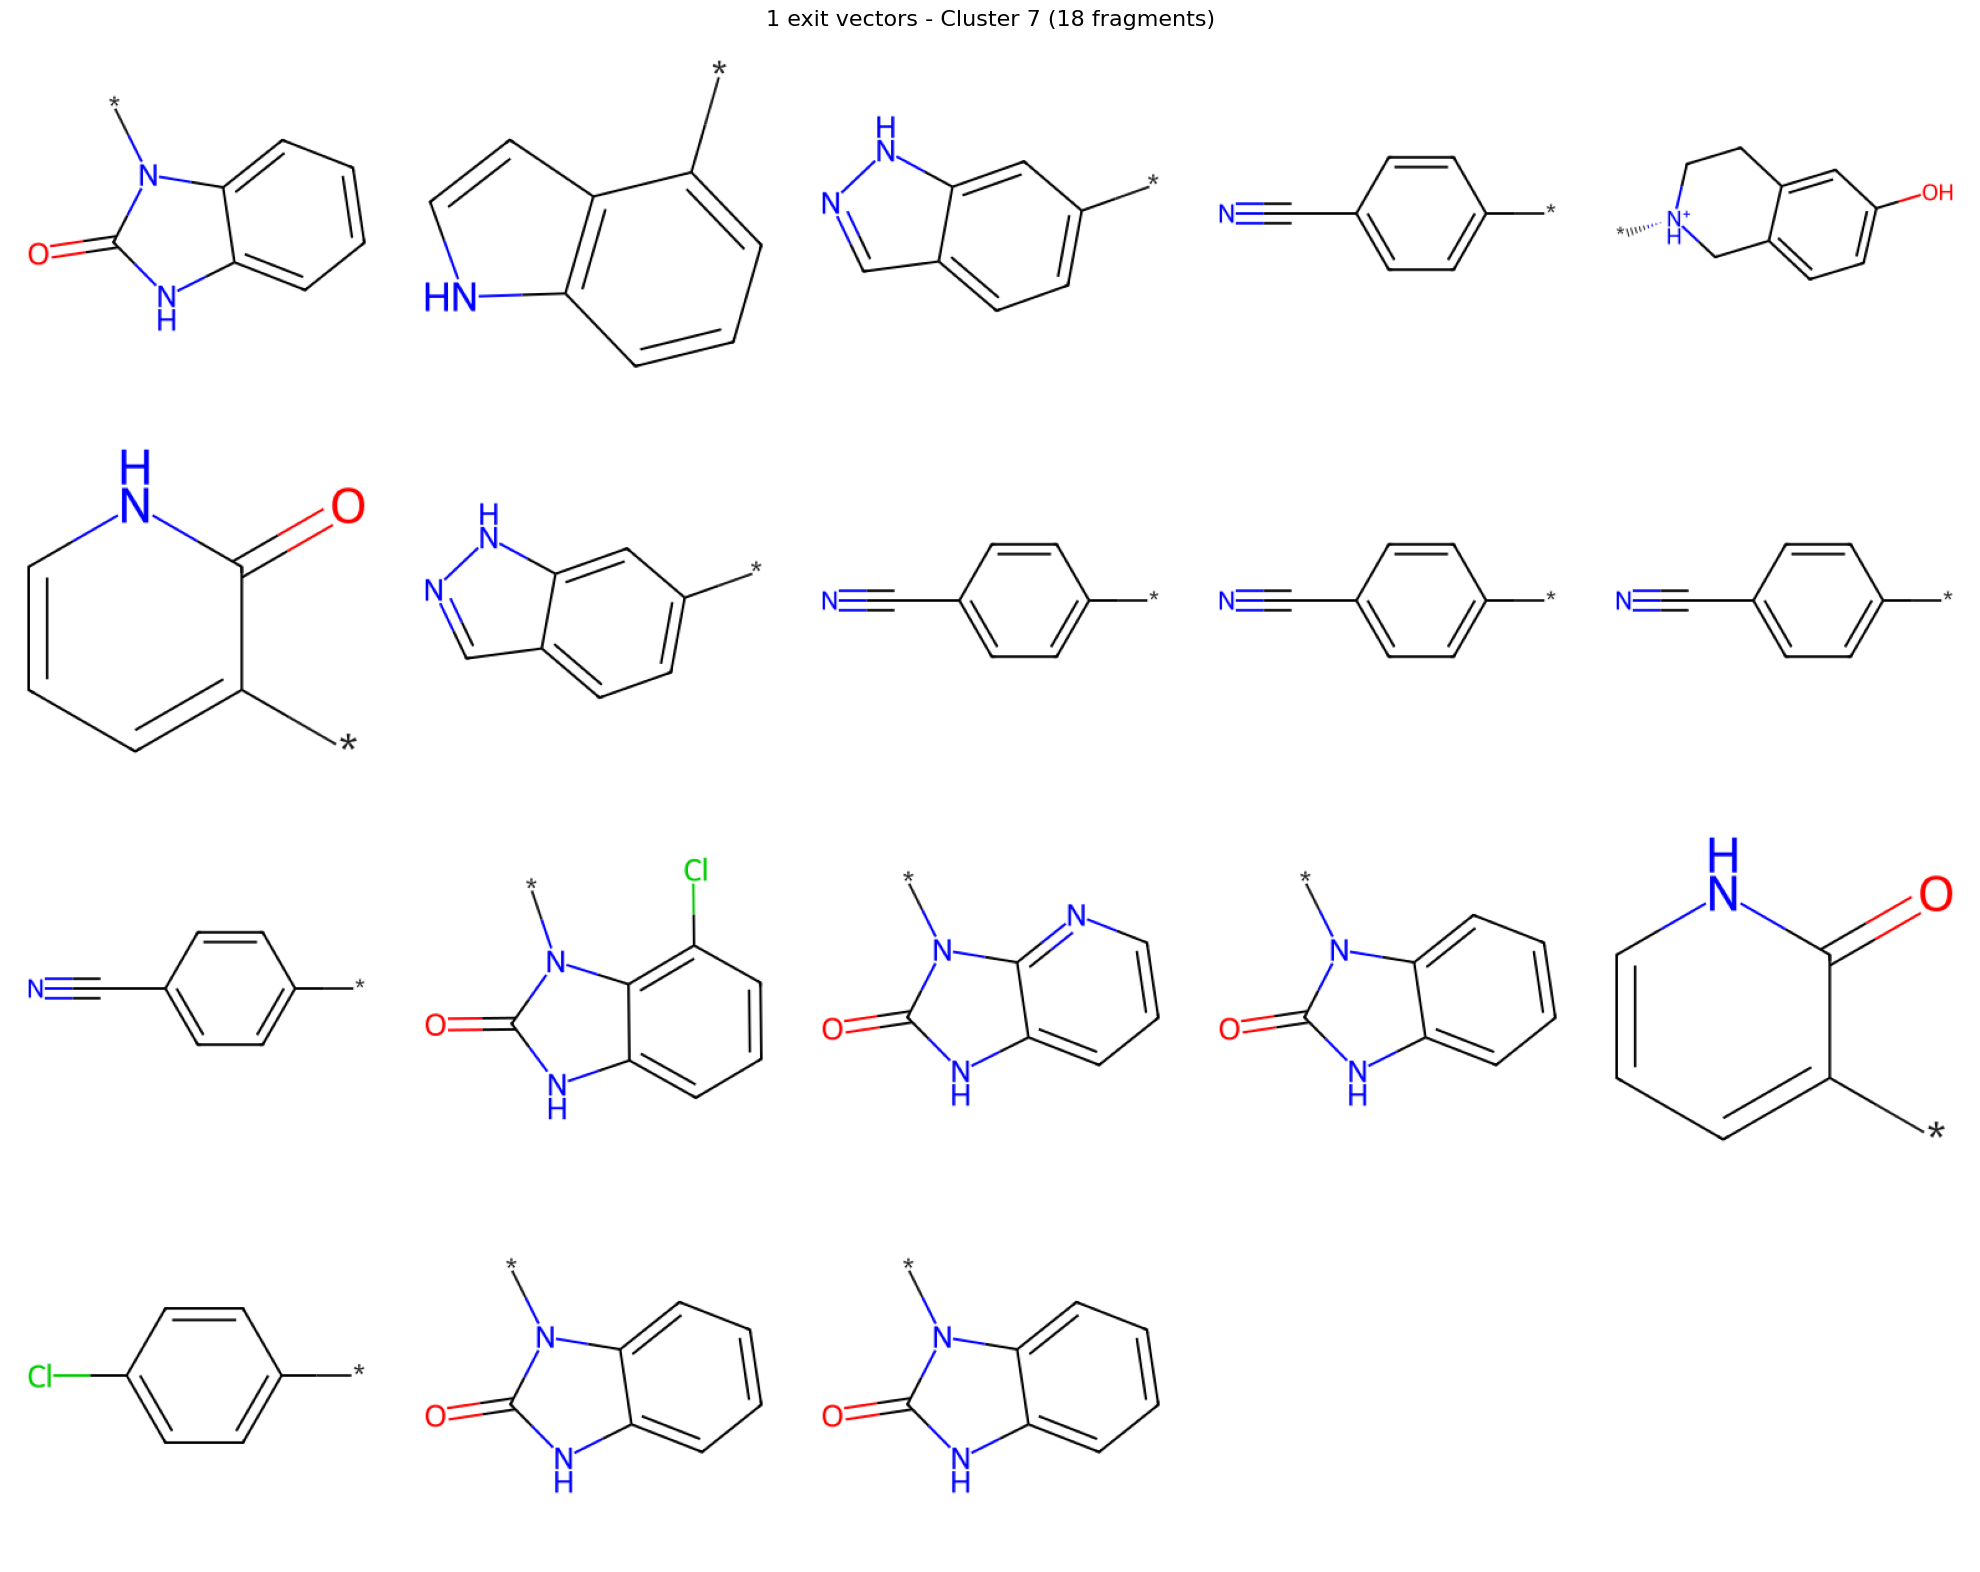

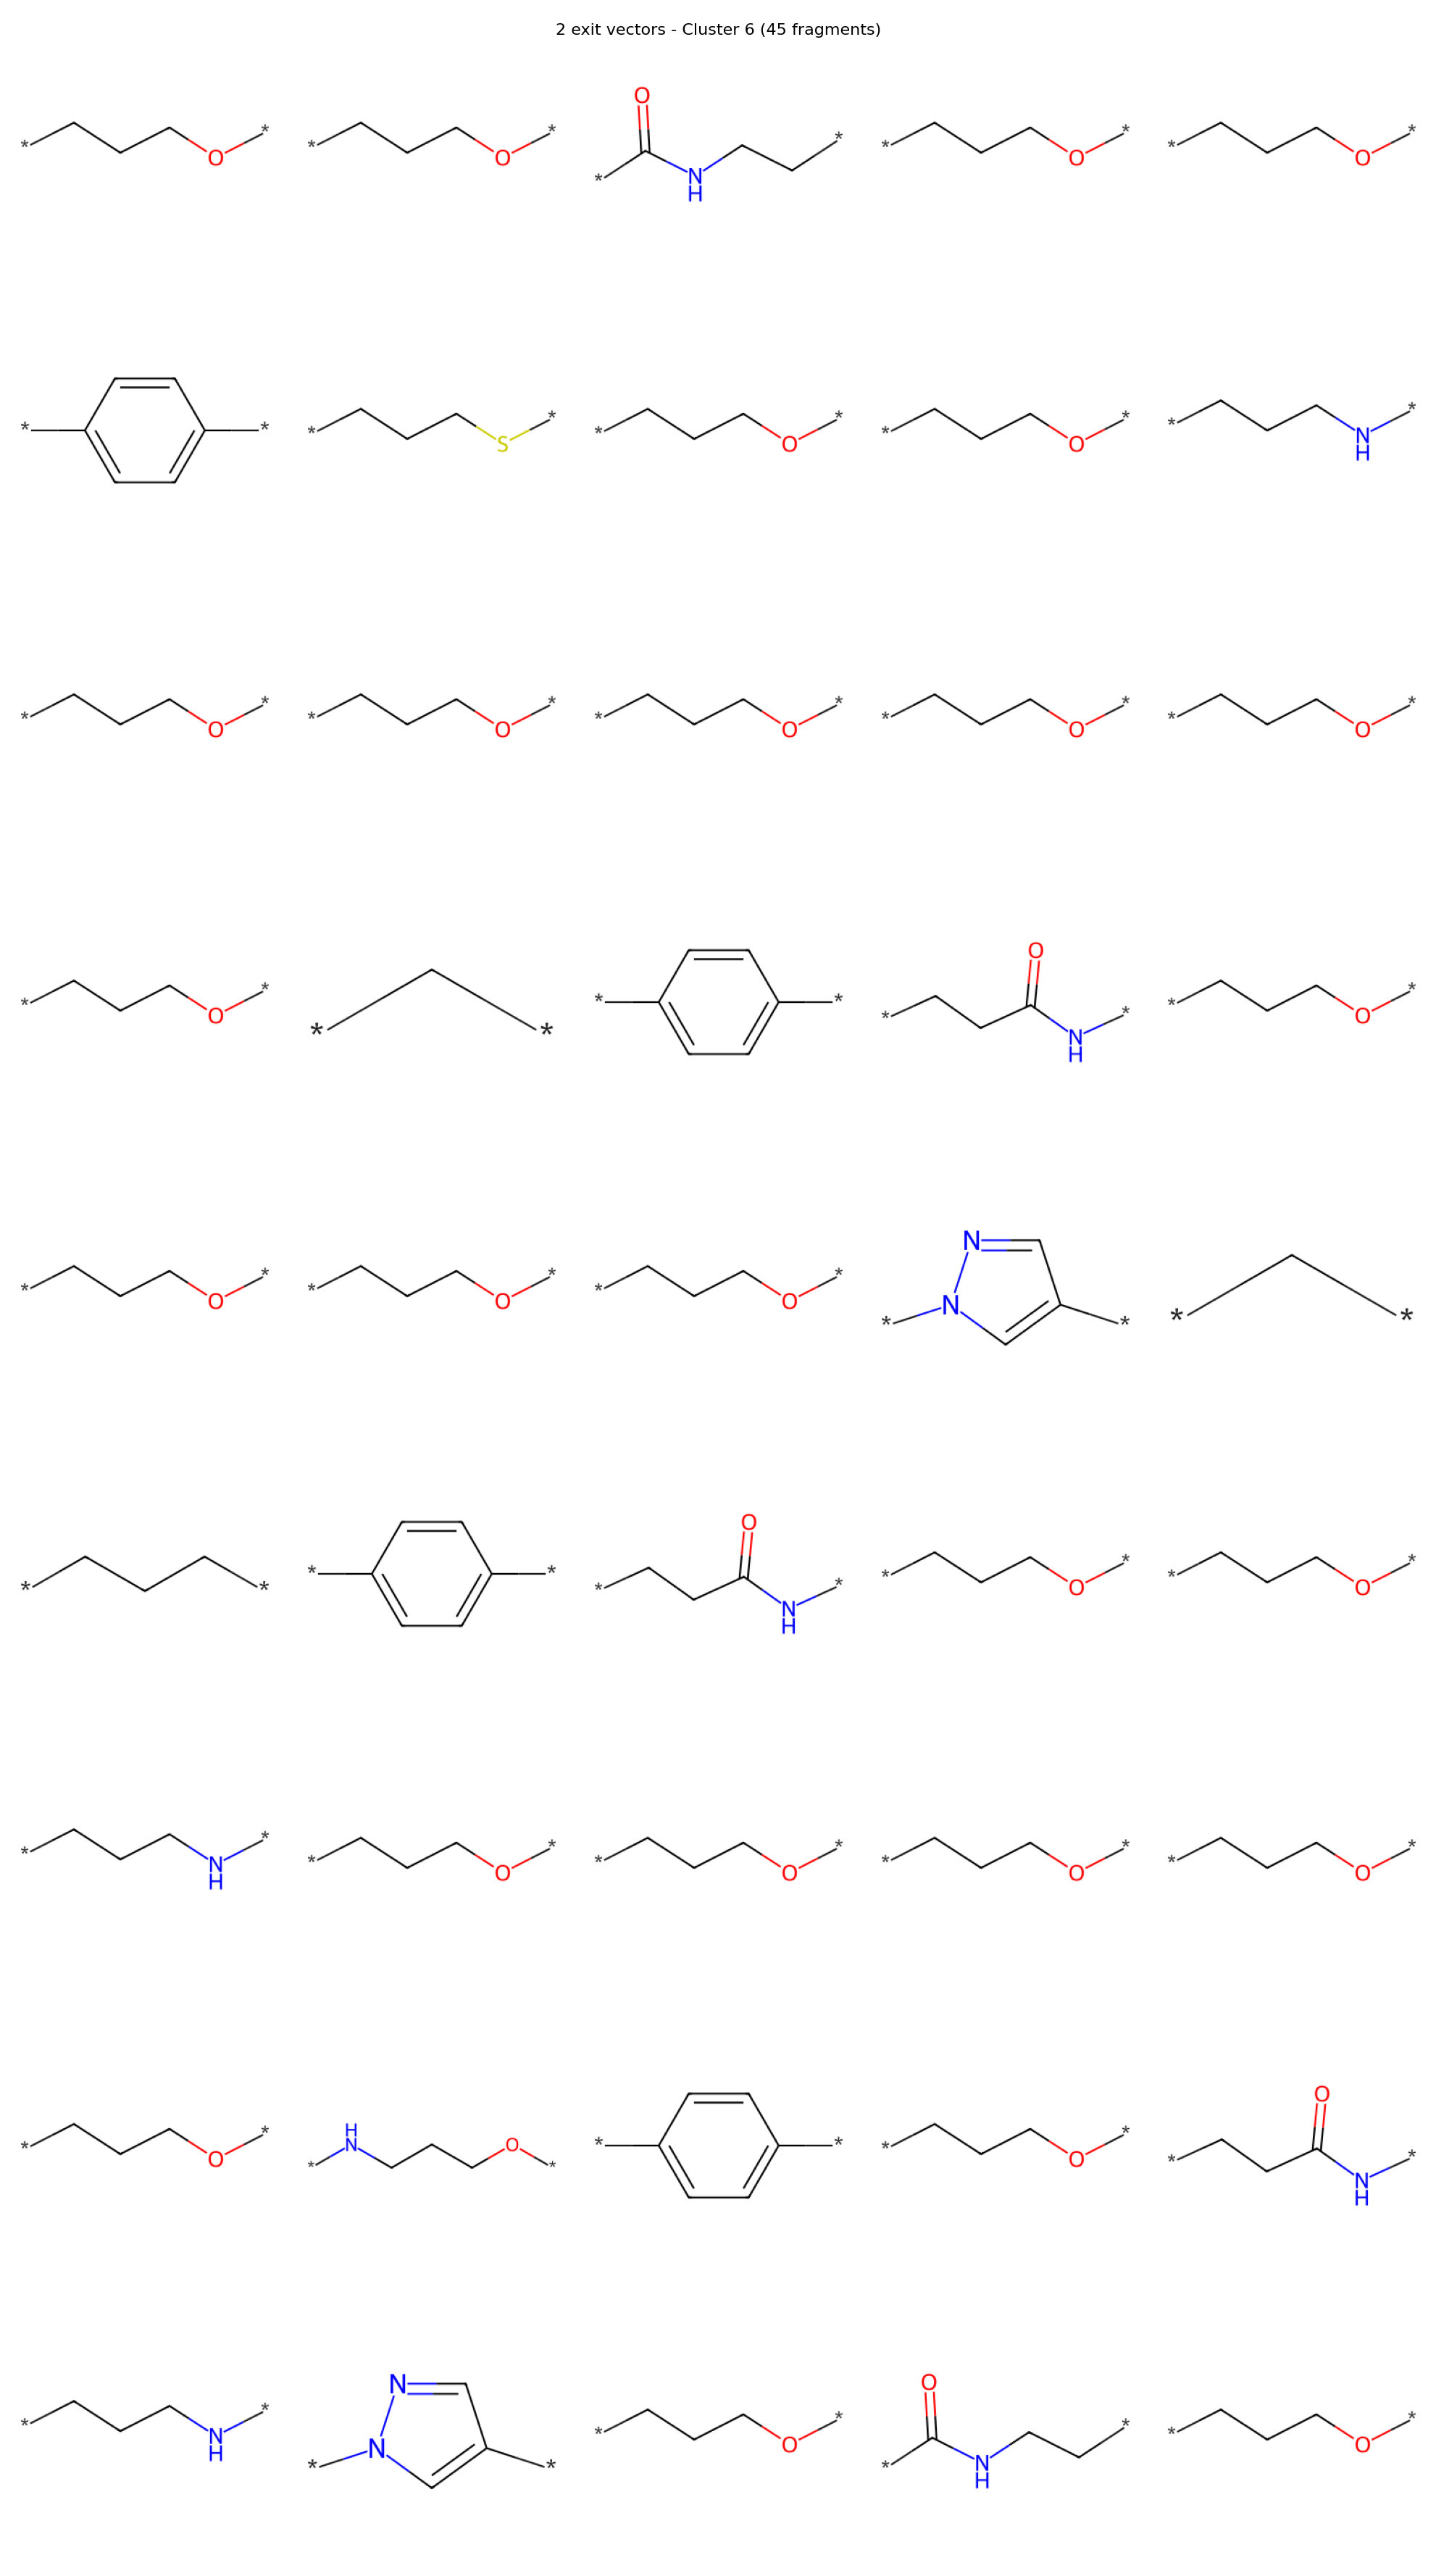

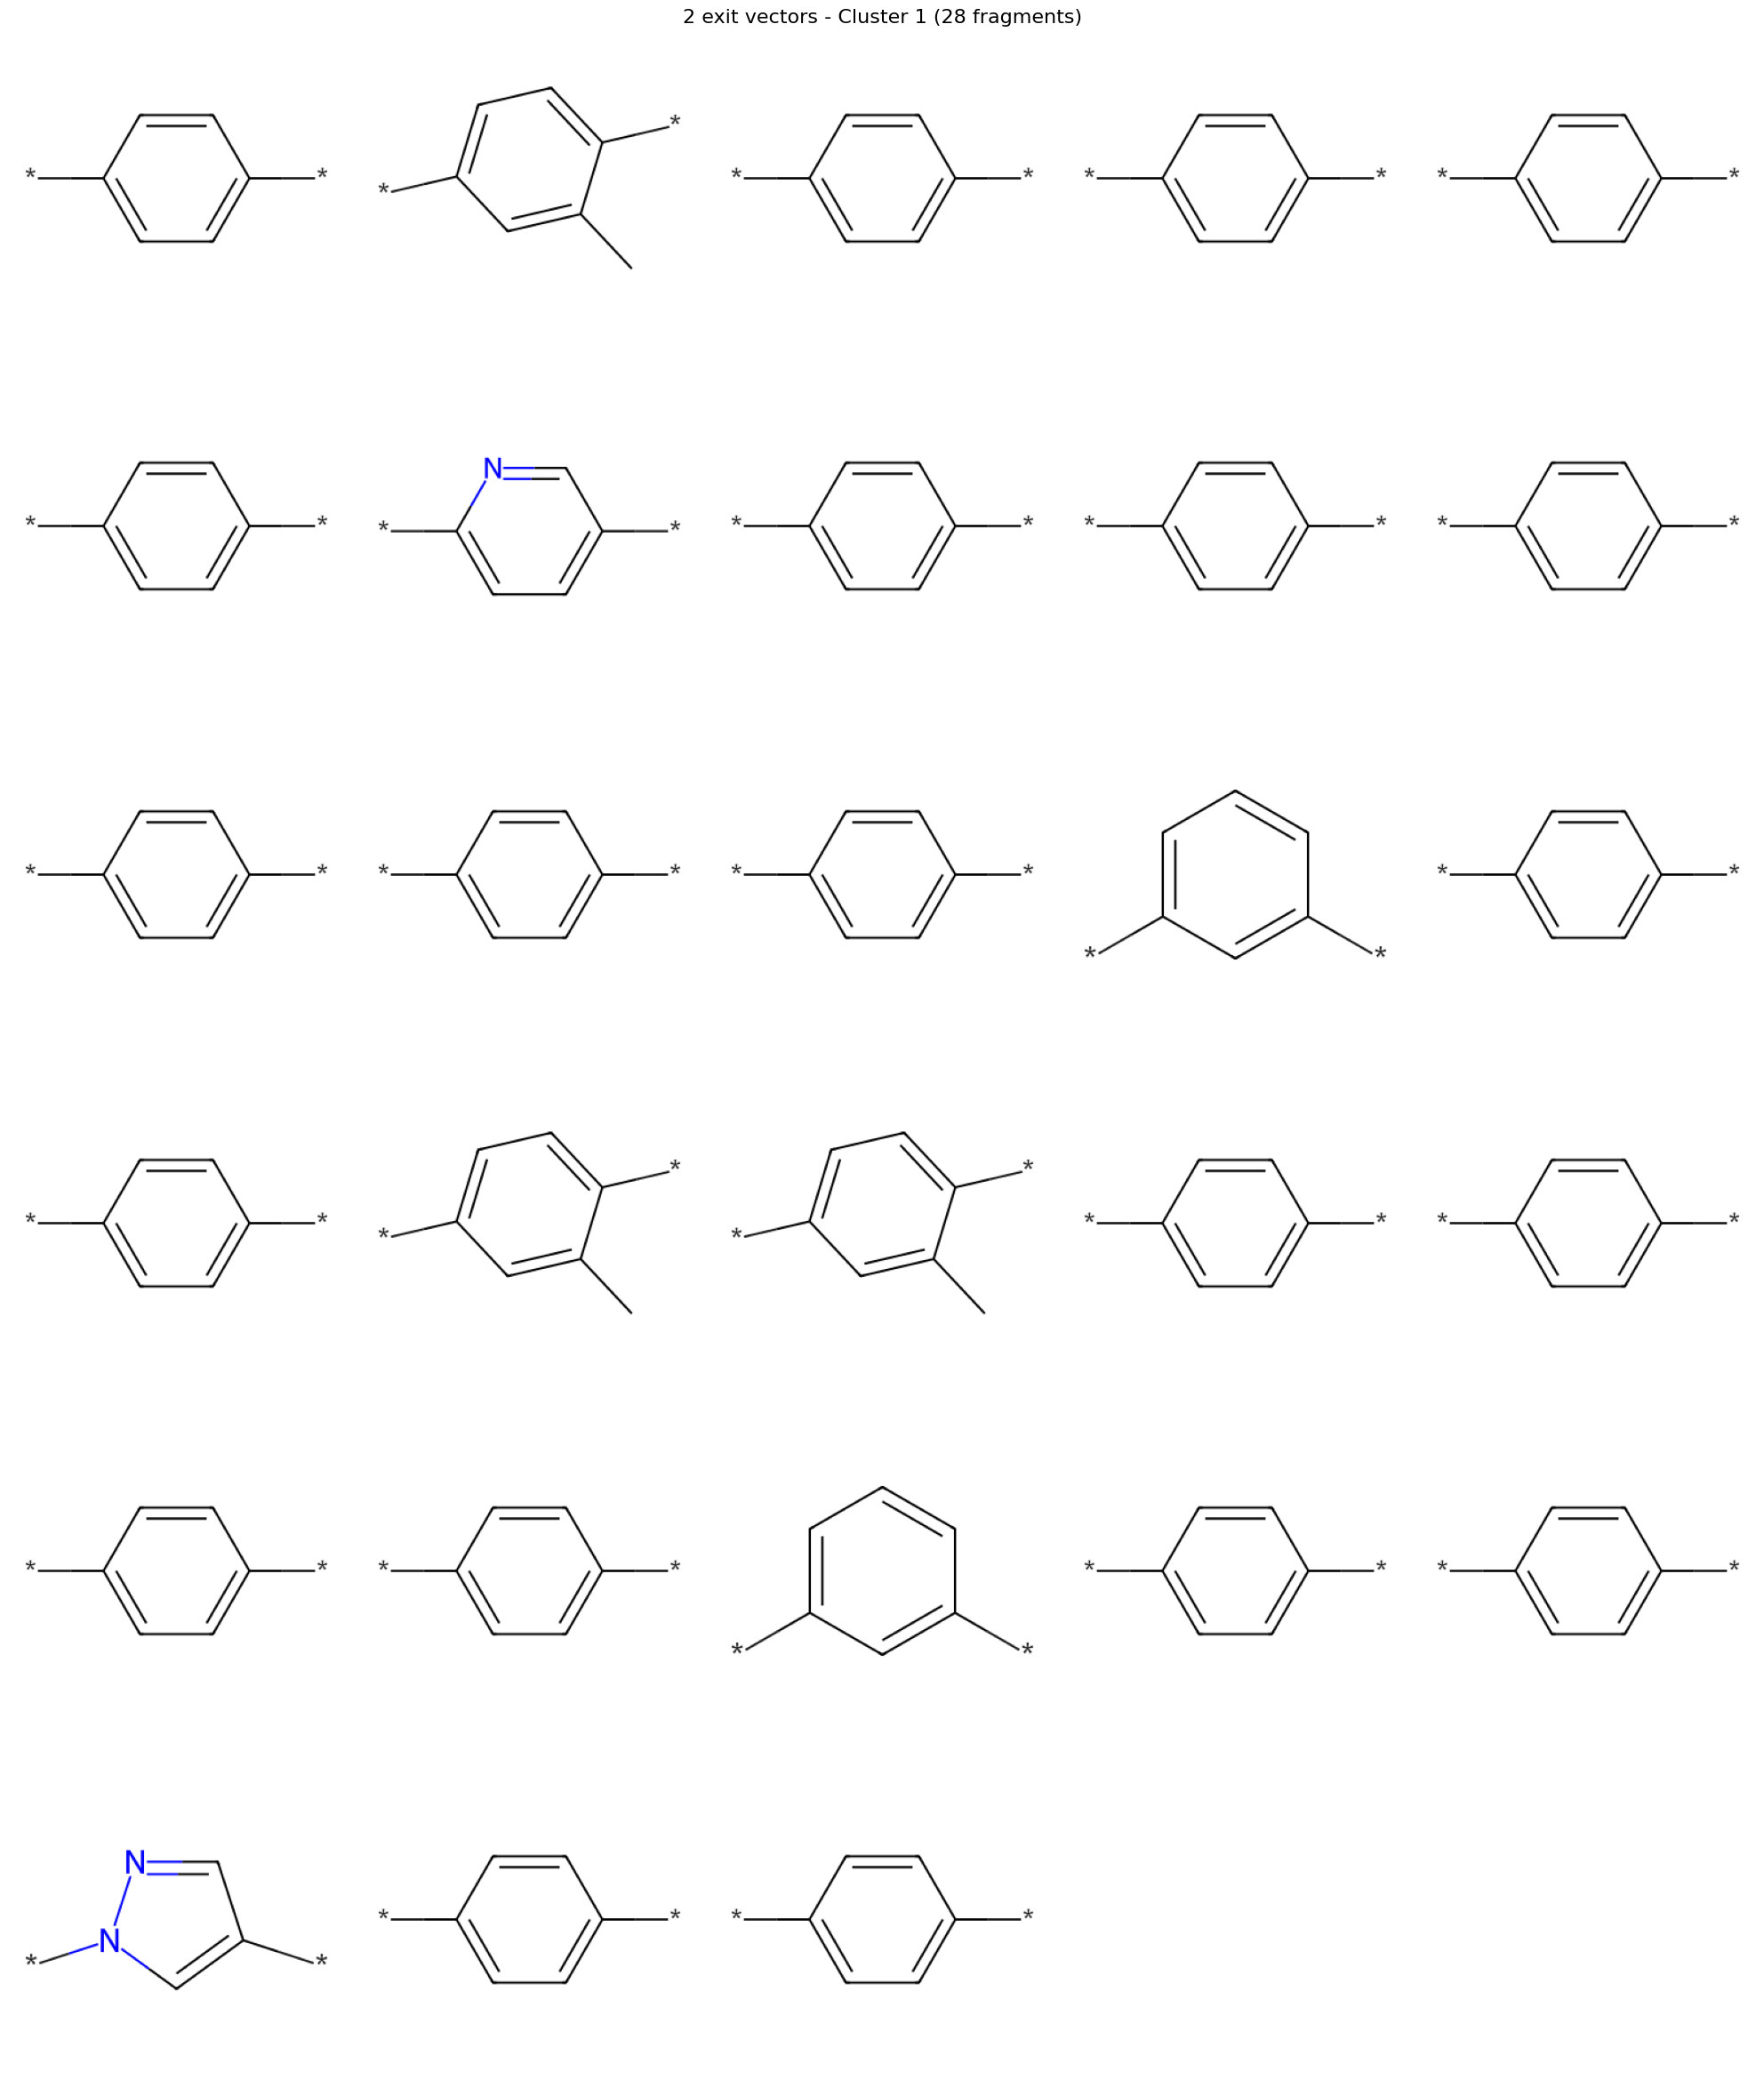

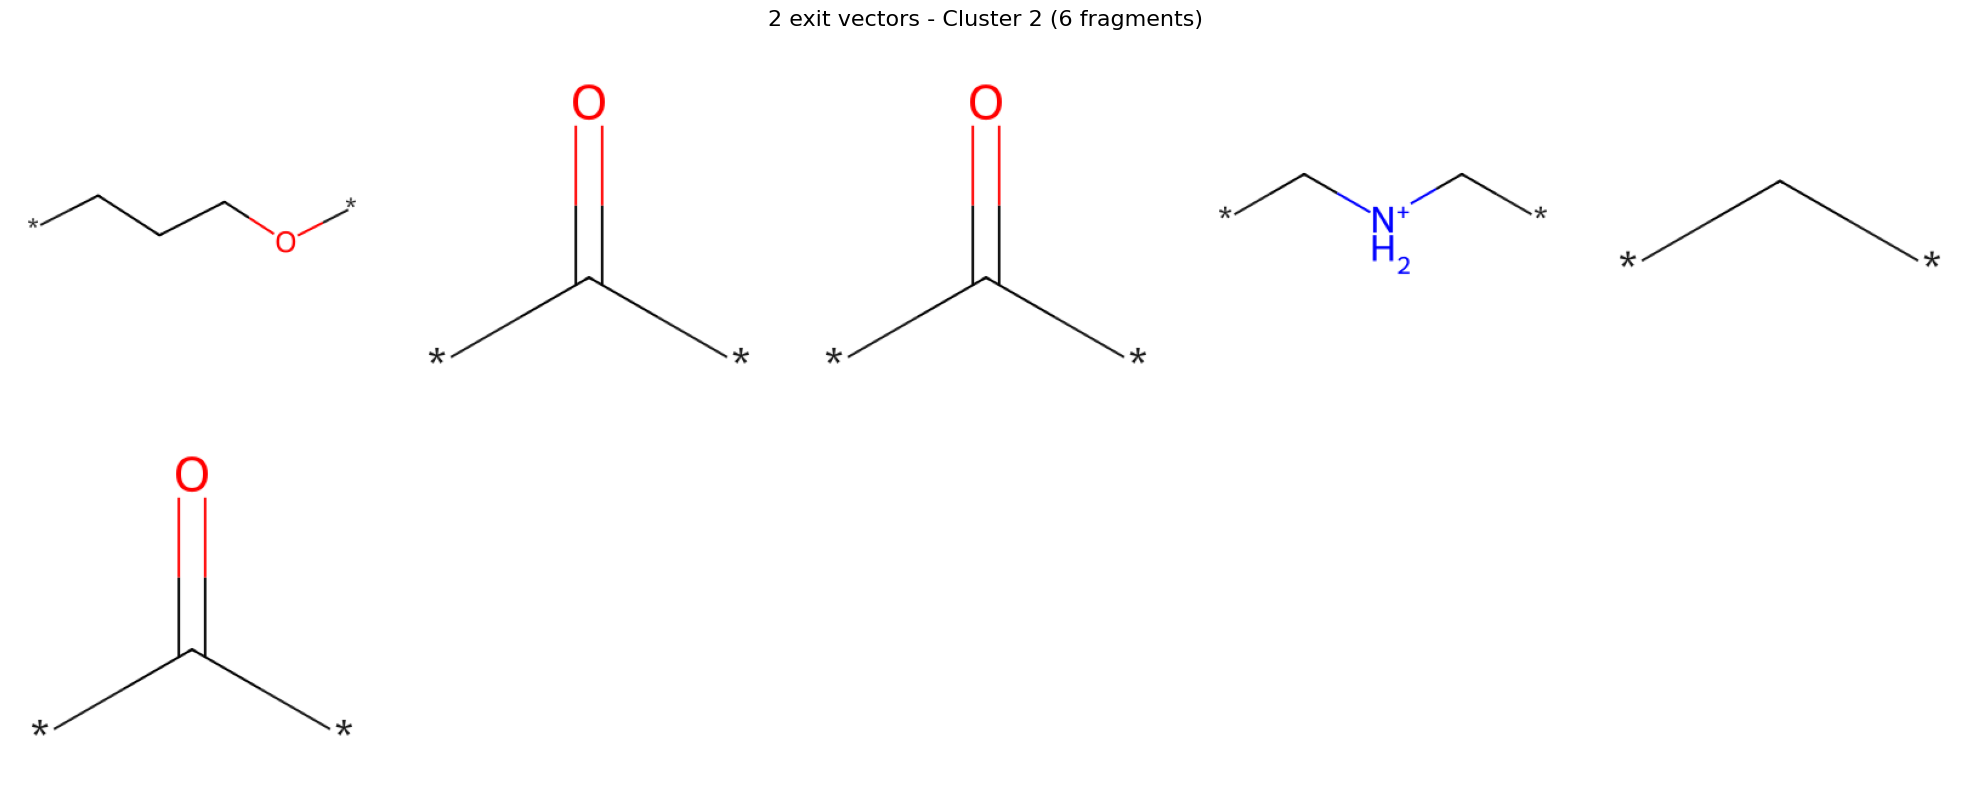

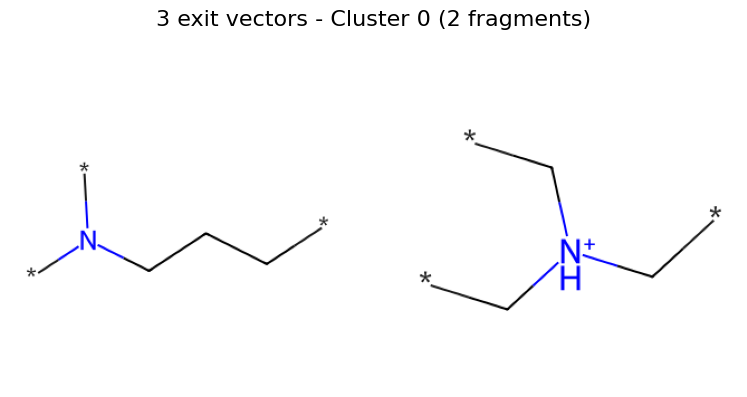

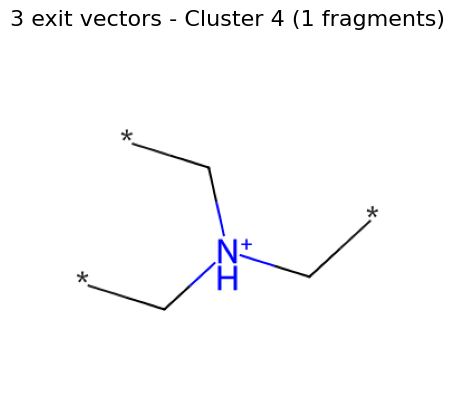

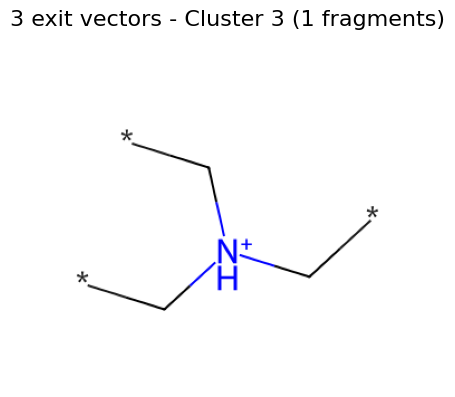

In [16]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# Function to visualize clusters
def visualize_cluster(fragments, title=""):
    # Create a figure with subplots for each fragment
    n_frags = len(fragments)
    n_cols = min(5, n_frags)  # Max 5 molecules per row
    n_rows = (n_frags + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(4*n_cols, 4*n_rows))
    plt.suptitle(title, fontsize=16)
    
    for i, frag in enumerate(fragments):
        mol = Chem.MolFromSmiles(frag['smiles'])
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        img = Draw.MolToImage(mol)
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize largest clusters for each exit vector category
for n_exits, clusters in clustered_fragments.items():
    # Sort clusters by size
    sorted_clusters = sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)
    
    # Show top 3 largest clusters
    for cluster_id, cluster in sorted_clusters[:3]:
        title = f"{n_exits} exit vectors - Cluster {cluster_id} ({len(cluster)} fragments)"
        visualize_cluster(cluster, title)

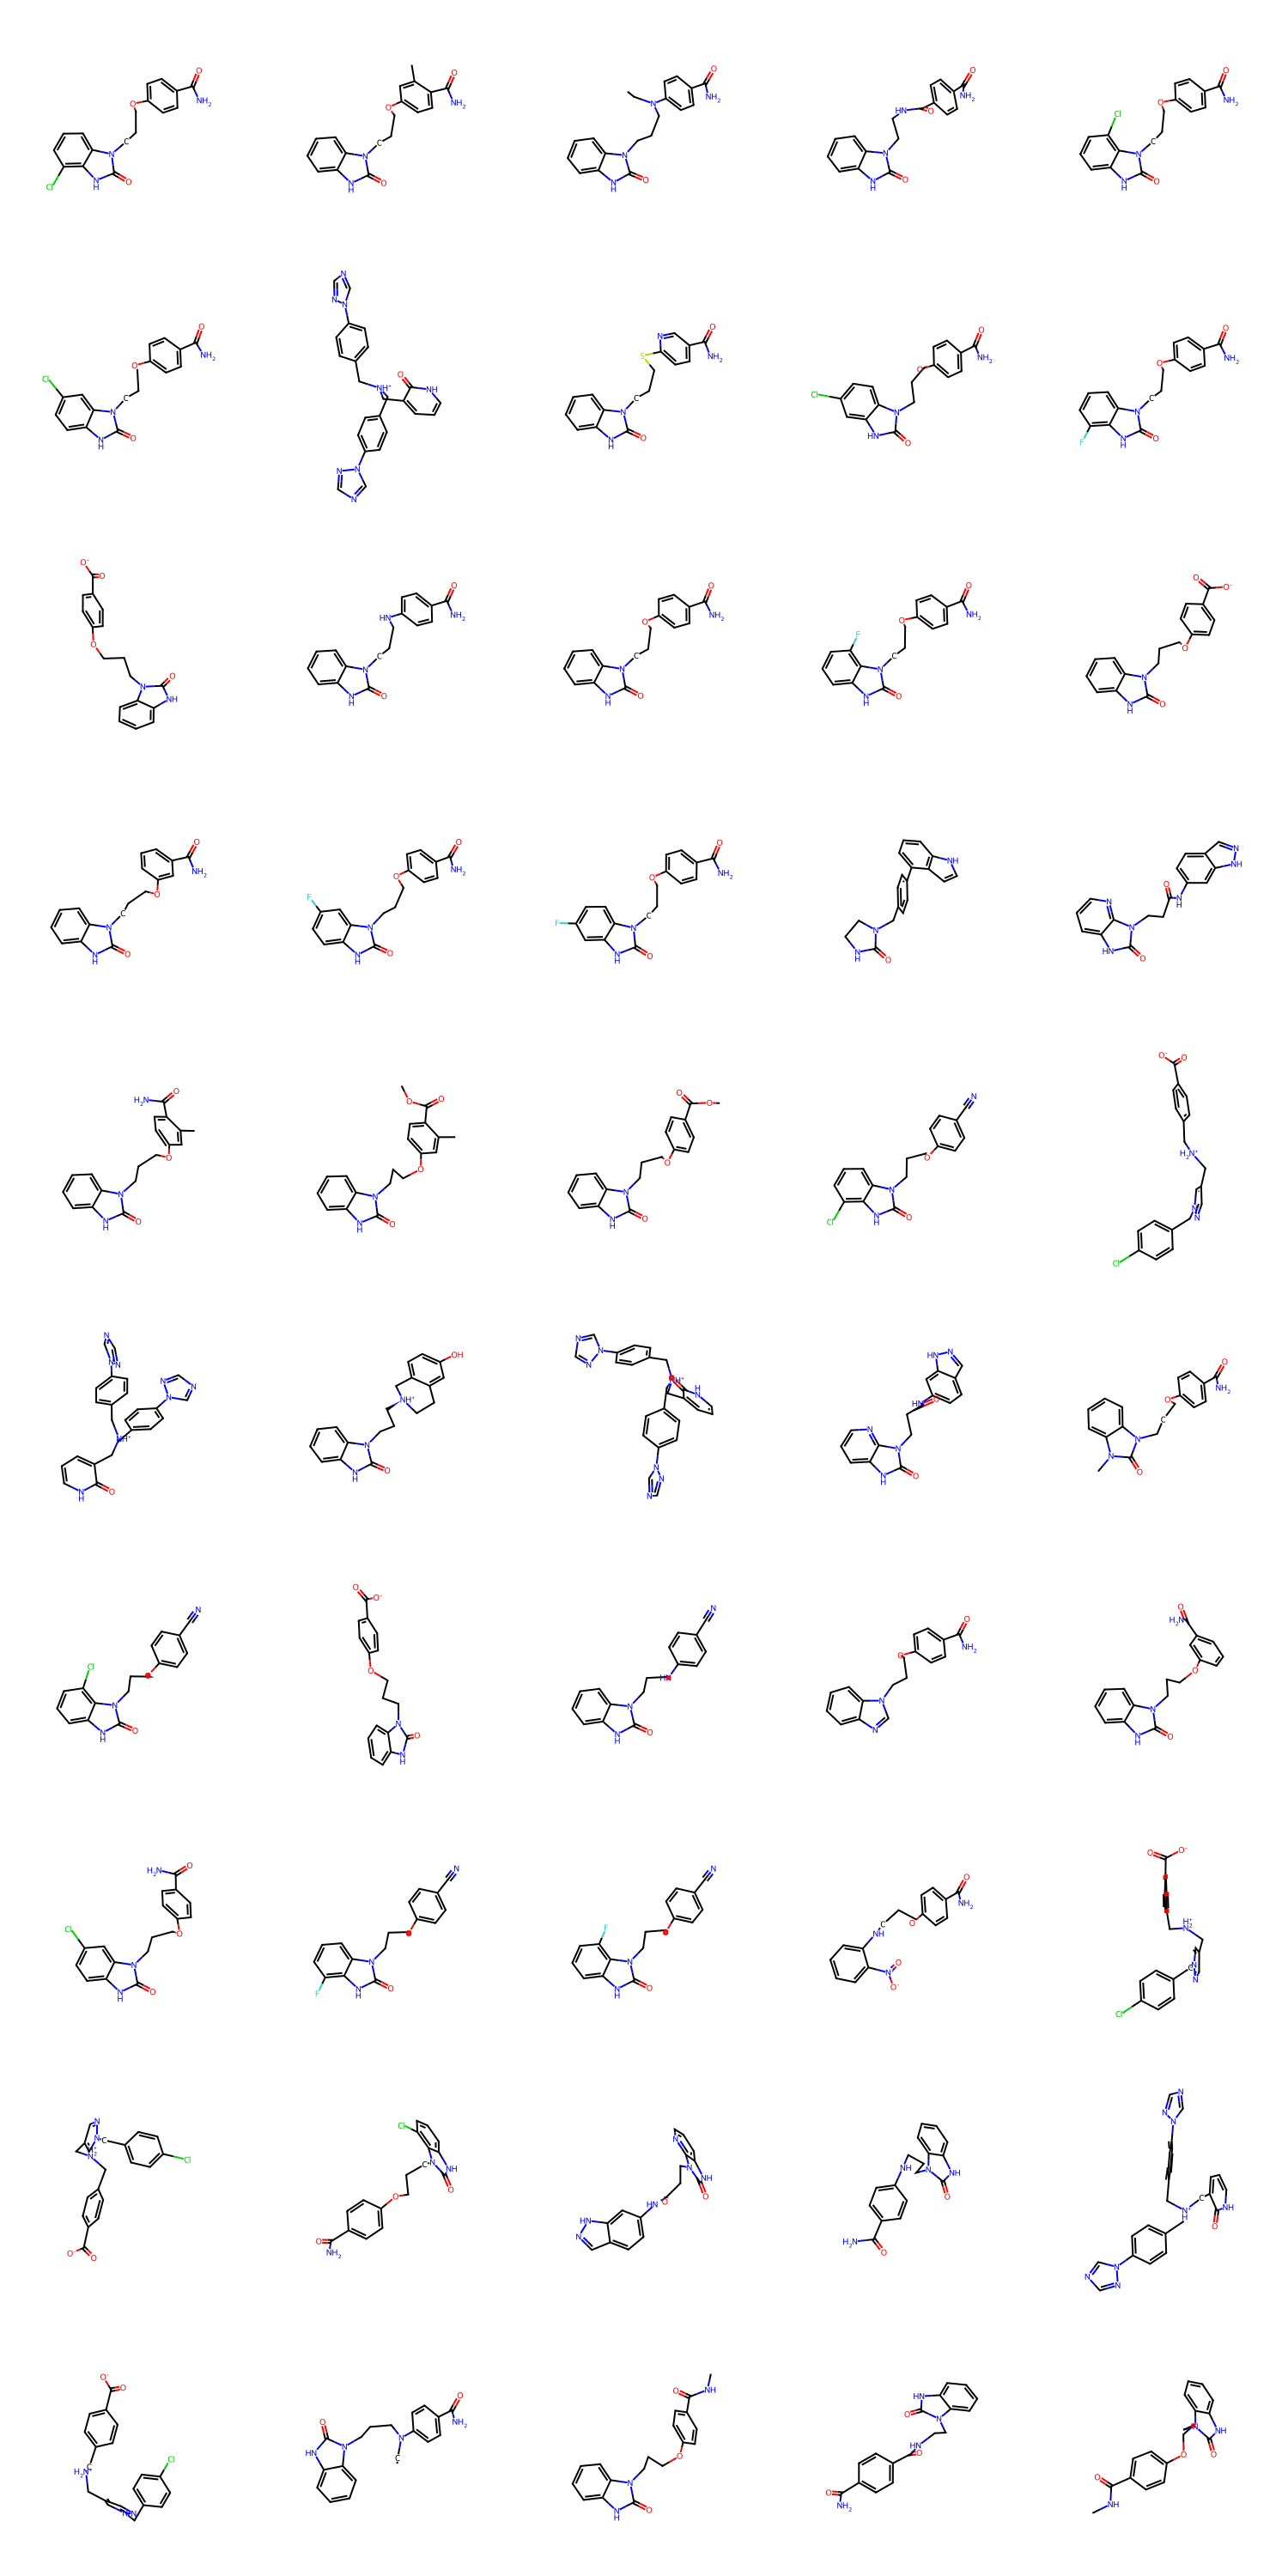

In [17]:
# Draw all molecules in a single grid
img = Draw.MolsToGridImage(mols[0:50], molsPerRow=5, subImgSize=(300,300))
display(img)

[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerator
[13:22:31] DEPRECATION WARNING: please use MorganGenerat

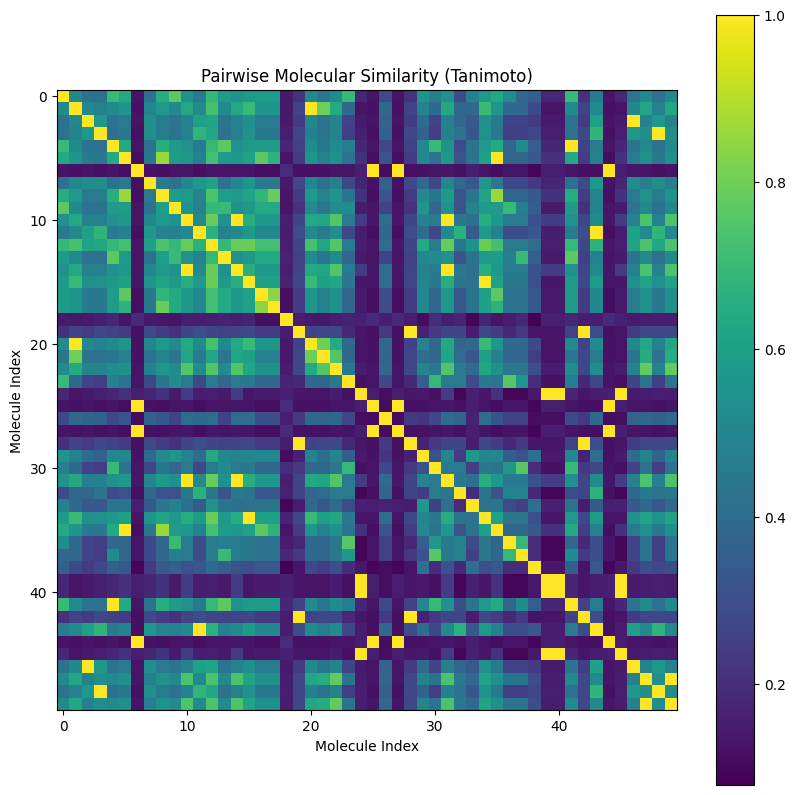

In [18]:
from rdkit import DataStructs
from rdkit.Chem import AllChem
import numpy as np

# Generate Morgan fingerprints for all molecules
fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2) for mol in mols[0:50]]

# Calculate pairwise similarities
n_mols = len(mols[0:50])
similarity_matrix = np.zeros((n_mols, n_mols))

for i in range(n_mols):
    for j in range(n_mols):
        similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarity_matrix[i,j] = similarity

# Visualize similarity matrix
plt.figure(figsize=(10,10))
plt.imshow(similarity_matrix, cmap='viridis')
plt.colorbar()
plt.title('Pairwise Molecular Similarity (Tanimoto)')
plt.xlabel('Molecule Index')
plt.ylabel('Molecule Index')
plt.show()

In [19]:
clustered_fragments

{1: {np.int64(1): [{'smiles': '*C(N)=O',
    'centroid': array([ 9.515     ,  2.13533333, 10.38333333])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.50133333,  2.10133333, 10.40833333])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.29666667,  2.24533333, 10.38166667])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.13666667,  2.153     , 10.44433333])},
   {'smiles': '*C(N)=O', 'centroid': array([ 9.517,  2.117, 10.398])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.55433333,  2.20433333, 10.14066667])},
   {'smiles': '*c1ccc[nH]c1=O',
    'centroid': array([8.19785714, 2.57928571, 9.77757143])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.43966667,  2.17566667, 10.411     ])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.382     ,  2.14933333, 10.20533333])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.52366667,  2.09266667, 10.39333333])},
   {'smiles': '*C(N)=O',
    'centroid': array([ 9.521     ,  2.11133333, 10.36933333])},
   {'smil

In [59]:
# Take one molecule as an example
test_mol = mols[1]

# Fragment the molecule and get centroids
ends = find_connected_rotatable_bond_ends(test_mol)
centroids = compute_fragment_centroids(test_mol, ends)

print(centroids)

def find_cluster(smiles, centroid, clustered_fragments):
    # Iterate through each cluster level
    for cluster_level, fragments in clustered_fragments.items():
        # Iterate through each fragment group in this level
        for group_id, group_fragments in fragments.items():
            # Check each fragment in the group
            for fragment in group_fragments:
                # Compare SMILES and check if centroids are close
                if fragment['smiles'] == smiles and np.allclose(fragment['centroid'], centroid, atol=0.1):
                    return cluster_level, group_id
    
    # Return None if no matching cluster is found
    return None

for frag in centroids:
    smiles = frag[3]
    centroid = frag[1]
    cluster = find_cluster(smiles, centroid, clustered_fragments)
    print(cluster)

[((0, 1, 2, 3, 18, 19, 20), array([6.91357143, 1.778     , 8.65771429]), 2, '*c1ccc(*)c(C)c1'), ((4, 5, 6, 7), array([ 4.97775, -0.59075,  5.3625 ]), 2, '*CCCO*'), ((8, 9, 10, 11, 12, 13, 14, 15, 16, 17), array([ 1.7304, -3.2263,  4.6505]), 1, '*n1c(=O)[nH]c2ccccc21'), ((21, 22, 23), array([ 9.50133333,  2.10133333, 10.40833333]), 1, '*C(N)=O')]
(2, np.int64(1))
(2, np.int64(6))
(1, np.int64(0))
(1, np.int64(1))


In [60]:
def get_random_fragment_from_cluster(cluster_level, group_id, clustered_fragments):
    # Get all fragments in the specified cluster
    fragments = clustered_fragments[cluster_level][group_id]

    smiles = [frag['smiles'] for frag in fragments]
    smiles = list(set(smiles))

    print(len(smiles))
    
    # Randomly select one fragment
    return random.choice(smiles)

# For each fragment in the test molecule, get a random fragment from its cluster
random_fragments = []
for frag in centroids:
    smiles = frag[3]
    centroid = frag[1]
    cluster = find_cluster(smiles, centroid, clustered_fragments)
    
    if cluster is not None:
        cluster_level, group_id = cluster
        random_frag = get_random_fragment_from_cluster(cluster_level, group_id, clustered_fragments)
        random_fragments.append(random_frag)
    else:
        print(f"No cluster found for fragment {smiles}")

print("\nRandomly selected fragments:")
for frag in random_fragments:
    print(frag)

5
10
19
5

Randomly selected fragments:
*c1cnn(*)c1
*NCCCO*
*n1c(=O)[nH]c2ccc(Cl)cc21
*C(N)=O


In [61]:
safecodec = SAFECodec(slicer=find_connected_rotatable_bond_ends)

In [62]:
# Connect fragments sequentially
linked_smiles = random_fragments[0]
for i in range(1, len(random_fragments)):
    linked_smiles = safecodec.link_fragments(linked_smiles, random_fragments[i])

In [63]:
print(linked_smiles)

c1(C(N)=O)cnn(OCCCNn2c(=O)[nH]c3ccc(Cl)cc23)c1


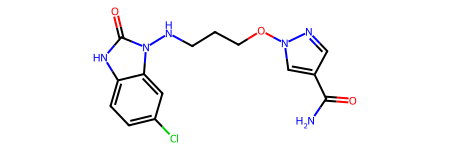

In [64]:
Chem.MolFromSmiles(linked_smiles)

Generated molecule is novel
Most similar molecule has Tanimoto similarity of 0.464


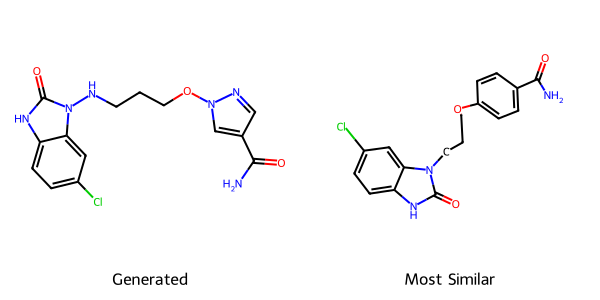

In [65]:
# Check if linked_smiles exists and find most similar molecule
max_similarity = 0
most_similar_mol = None
found = False

# Create Morgan fingerprint for the linked molecule
linked_mol = Chem.MolFromSmiles(linked_smiles)
linked_fp = AllChem.GetMorganFingerprintAsBitVect(linked_mol, 2)

for mol in mols:
    mol_smiles = Chem.MolToSmiles(mol)
    if mol_smiles == linked_smiles:
        print("Generated molecule already exists in dataset")
        found = True
        break
    else:
        # Calculate similarity
        mol_fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2)
        similarity = DataStructs.TanimotoSimilarity(linked_fp, mol_fp)
        if similarity > max_similarity:
            max_similarity = similarity
            most_similar_mol = mol

if not found:
    print("Generated molecule is novel")
    print(f"Most similar molecule has Tanimoto similarity of {max_similarity:.3f}")
    # Draw both molecules side by side
    img = Draw.MolsToGridImage([linked_mol, most_similar_mol], 
                             legends=['Generated', 'Most Similar'],
                             molsPerRow=2,
                             subImgSize=(300,300))
    display(img)

In [6]:
# Read in generated molecules
with open('generated_molecules.smi', 'r') as f:
    generated_smiles = [line.strip() for line in f.readlines()]

print(f"Read {len(generated_smiles)} generated molecules")

Read 7523 generated molecules


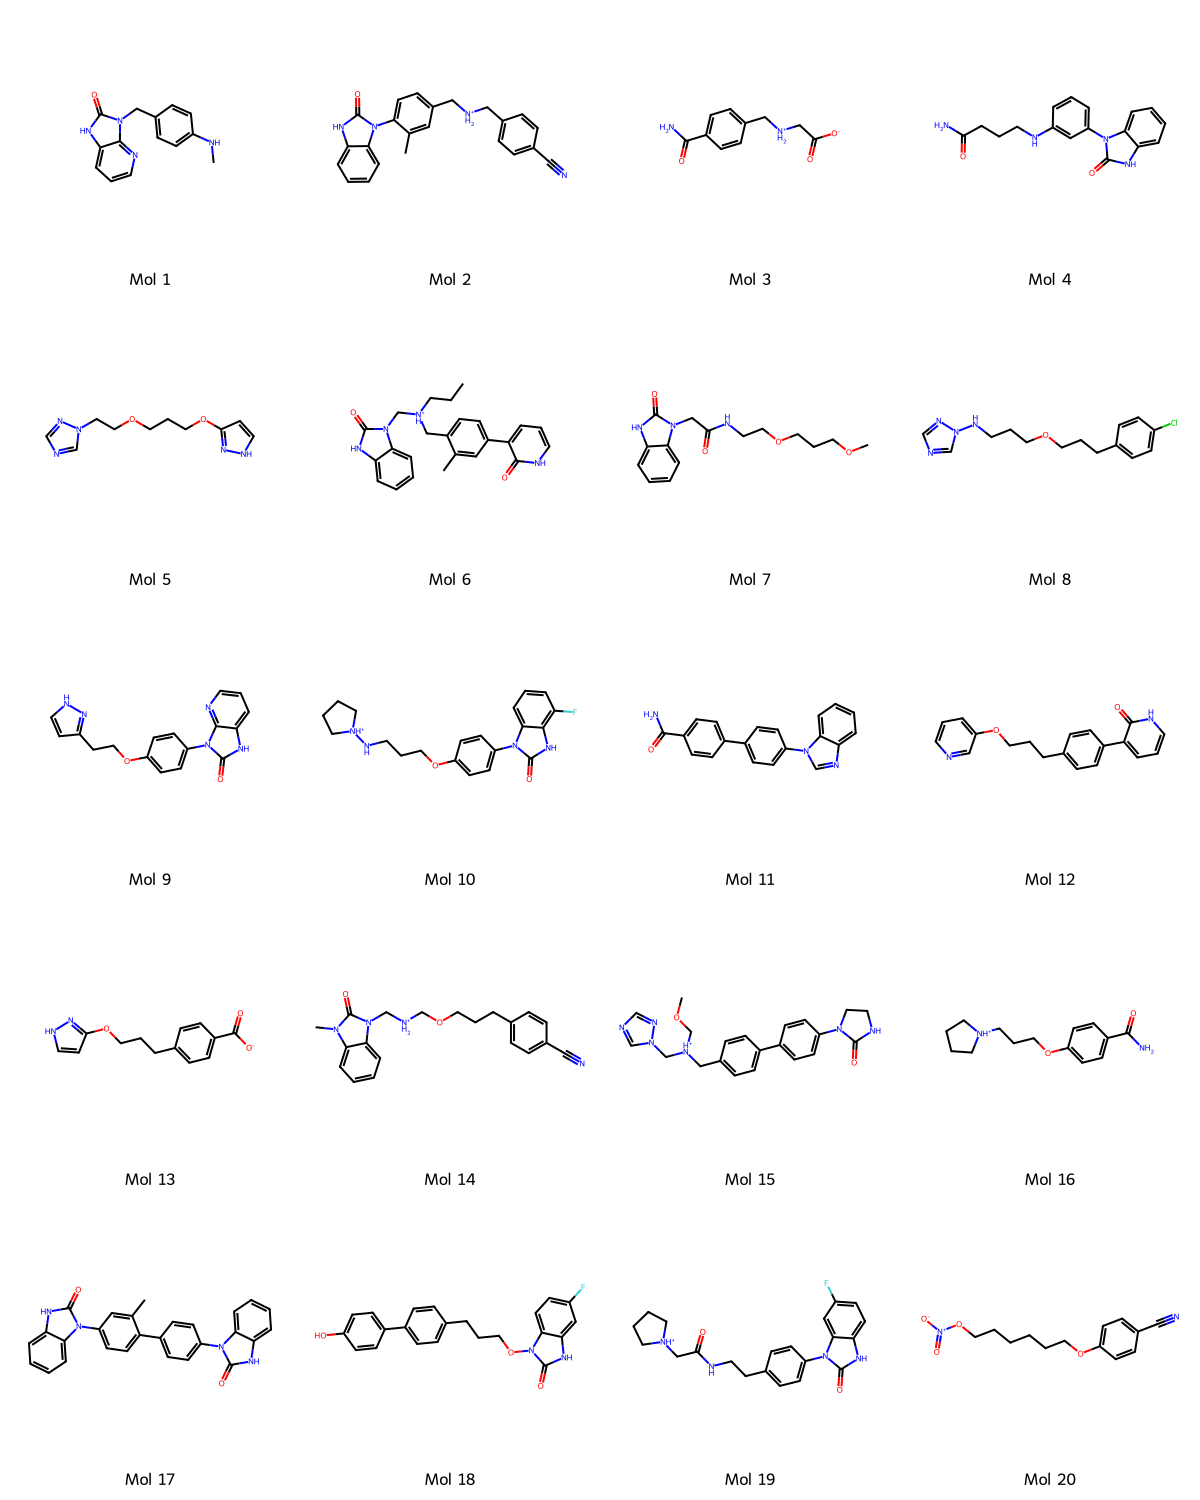

In [7]:
from rdkit import Chem
from rdkit.Chem import Draw

# Get first 20 molecules
mols_to_draw = [Chem.MolFromSmiles(smi) for smi in generated_smiles[20:40]]

# Draw molecules in a grid
img = Draw.MolsToGridImage(mols_to_draw,
                          molsPerRow=4,
                          subImgSize=(300,300),
                          legends=[f'Mol {i+1}' for i in range(20)])
display(img)